# JUMP CRISPR → AnnData

The assembled CRISPR arm of JUMP ([`cpg0016`](https://broadinstitute.github.io/cellpainting-gallery/)), the largest Cell Painting resource to date, as one published table rather than per-plate profiles. The obs are deliberately spare: a plate, a well and a JUMP perturbation id, with 148 plates and no low-cardinality covariate to colour by, and 148 plates exceed what a categorical palette can distinguish, so the embedding is shown uncoloured and the enrichment table below carries the quantitative answer.

One observation is a well, one variable is a CellProfiler feature.
Well-level profiles only, no images:

```bash
aws s3 cp --no-sign-request --recursive --exclude "*" --include "profiles_wellpos_cc_var_mad_outlier_featselect.parquet" \
  s3://cellpainting-gallery/cpg0016-jump-assembled/source_all/workspace/profiles/ .
```

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import scanpy as sc

import cell_painting_io as cpio

PROFILES = Path("~/data/cpg0016-jump-assembled/profiles").expanduser()

In [2]:
files = sorted(PROFILES.glob("CRISPR/*.parquet"))
print(f"{len(files)} plates")

1 plates


In [3]:
adata = cpio.read_profiles(files, index_columns=["Source", "Plate", "Well"])
adata

AnnData object with n_obs × n_vars = 51185 × 599
    obs: 'Source', 'Plate', 'Well', 'JCP2022'
    layers: None (.X)

In [4]:
cpio.annotate_features(adata.var)
adata = cpio.drop_incomplete_features(adata)
adata = cpio.drop_extreme_features(adata)
adata = cpio.drop_constant_features(adata)


def present(columns):
    return [c for c in columns if c in adata.obs.columns and adata.obs[c].nunique() > 1]


cpio.categorize(adata, present(["Source", "Plate"]))
adata.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
Cells_AreaShape_Compactness,cells,areashape,NaN,NaN,0
Cells_AreaShape_EulerNumber,cells,areashape,NaN,NaN,0
Cells_AreaShape_Zernike_0_0,cells,areashape,NaN,NaN,0
Cells_AreaShape_Zernike_1_1,cells,areashape,NaN,NaN,0
Cells_AreaShape_Zernike_2_0,cells,areashape,NaN,NaN,0
...,...,...,...,...,...
Nuclei_Texture_InfoMeas1_Mito_10_01_256,nuclei,texture,mito,NaN,1
Nuclei_Texture_InfoMeas2_AGP_3_03_256,nuclei,texture,agp,NaN,1
Nuclei_Texture_InverseDifferenceMoment_AGP_10_00_256,nuclei,texture,agp,NaN,1


## Sanity checks

In [5]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features")
print(f"non-finite: {int((~np.isfinite(adata.X)).sum())} | max|x|: {np.abs(adata.X).max():.1f}")
for column in present(["Source"]):
    print(f"\n{column}:")
    print(adata.obs[column].value_counts(dropna=False).head(6).to_string())

51,185 wells x 599 features
non-finite: 0 | max|x|: 15676.8


In [6]:
adata.write_h5ad(PROFILES.parent / "jump_crispr.h5ad")

## UMAP

The profiles are already normalized, so they enter PCA unscaled.

In [7]:
sc.pp.pca(adata, n_comps=min(50, adata.n_vars - 1))
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


How often do neighbouring wells share a label, against the rate expected if labels were shuffled?
Above 1 means the covariate explains part of the embedding.

In [8]:
cpio.neighbour_enrichment(adata, present(["Source", "Plate", "JCP2022"]))

,observed,baseline,ratio
covariate,,,
Plate,0.029,0.007,4.354
JCP2022,0.075,0.012,6.480


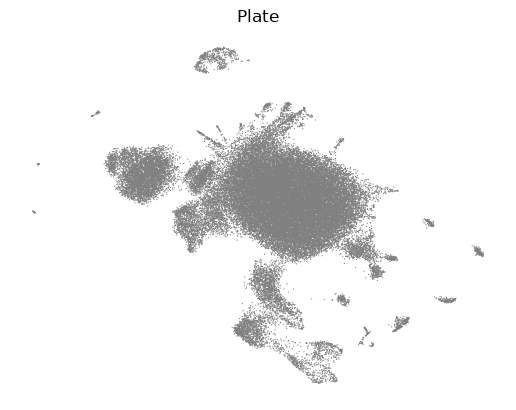

In [9]:
sc.pl.umap(adata, color=present(["Plate"])[:3], ncols=3, frameon=False, size=3, legend_loc="none")